In [85]:
import pandas as pd
import numpy as np
import math 

In [4]:
data=pd.read_csv("student_performance.csv")

1. Understanding the Basics
- Explain in your own words:
- What is Probability?
- Key Probability Terminology.
- Give at least three probability event examples from the dataset.

In [ ]:
# 1. What is probability?
# Ans: - Probability is a measure of the likelihood that a particular event will occur.
# It quantifies uncertainty using a number between 0 and 1:
# • 0 means the event cannot happen
# • 1 means the event is certain to happen

# 2. Key probability terminology
# Ans: - Event: An outcome or a situation you're interested in.
# Example: "Passing the exam."

# Probability: The chance of an event happening, a number between 0 and 1.
# Example: The chance of passing the exam.

# Sample Space: All possible outcomes of an event.
# Example: For passing or failing the exam, the sample space is {Pass, Fail}.

# Mutually Exclusive Events: Two events that cannot happen at the same time.
# Example: "Pass" and "Fail" are mutually exclusive for the same student.

# Independent Events: Two events that don’t affect each other.
# Example: Attending class doesn't affect whether you pass the exam.

# Conditional Probability: The probability of one event happening given that another event has already happened.
# Example: The probability of passing the exam, given that a student attended more than 80% of classes.

# 3. Give at least three probability event examples from the dataset.
# Ans: - Three Examples from the Dataset:
# Ex1, Probability of passing the exam.
# Ex2, Probability of attending more than 80% of classes.
# Ex3, Probability of passing the exam given participation in group discussions.

2. Types of Events
- Identify one empirical probability and one theoretical probability scenario
from the dataset and calculate both.

In [121]:
# 1. Empirical Probability
# Scenario: Probability that a student passes the final exam (calculated from data)
empirical_pass_prob = (data["final_exam_pass"] == "Pass").sum() / len(data)
print(f"Empirical Probability of Passing: {empirical_pass_prob:.4f}")

# 2. Theoretical Probability
# Scenario: Probability that at least 1 student passes in 3 random selections
# Assuming each student has the same probability of passing 
# p indicate probability of randomly drawn student pass or not
p = empirical_pass_prob
theoretical_at_least_1_pass = 1 - (1 - p)**3
print(f"Theoretical Probability of at least 1 pass in 3 draws: {theoretical_at_least_1_pass:.4f}")


Empirical Probability of Passing: 0.5100
Theoretical Probability of at least 1 pass in 3 draws: 0.8824


3. Random Variable & Probability Distribution
- Define a random variable for the event "Number of students passing the final
exam" out of 3 randomly selected students.
- Construct its probability distribution table.
- Find the mean and variance of this random variable.

In [ ]:
np.random.seed(0)
drawn_students = np.random.choice(data["student_id"], size=3, replace=False)
x = 0 
for i in drawn_students: 
    if data.loc[data["student_id"] == i, "final_exam_pass"].values[0] == "Pass": 
        x += 1 
print(f"Total Students whose pass in final exam from drawn random three students is {x}")

Total Students whose pass in final exam from drawn random three students is 1


In [126]:
# now, construct the probability distribution table

n=drawn_students.size
p=(data["final_exam_pass"] == "Pass").sum()/len(data)

probability_dist_table={}
for i in range(len(drawn_students)):
    probability_dist_table[i]=round(math.comb(n,i)*((p)**i)*((1-p)**(n-i)),3)
print("Probability Distribution Table:")
for i,j in probability_dist_table.items():
    print(i,":",j)


Probability Distribution Table:
0 : 0.118
1 : 0.367
2 : 0.382


In [108]:
# now, calculate the mean and variance of random variable
n=drawn_students.size
p=(data["final_exam_pass"]=="Pass").sum()/len(data)

mean=n*p
variance=n*p*(1-p)

print("Mean:", round(mean, 3))
print("Variance:", round(variance, 3))

Mean: 1.53
Variance: 0.75


4. Venn Diagram in Probability
- Draw a Venn diagram showing:
- Students who study more than 10 hours/week.
- Students who attend more than 80% of classes.
- Overlap showing students who satisfy both conditions.

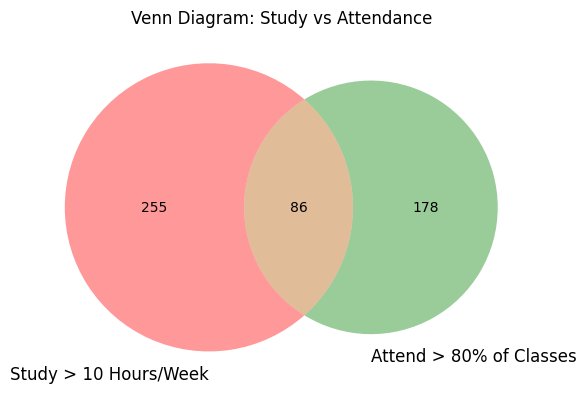

In [124]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Define the two conditions
study_more_than_10_hours = data[data["study_hours"] > 10]
attend_more_than_80 = data[data["attendance"] > 80]

# Find the students who satisfy both conditions (overlap)
both_conditions = pd.merge(study_more_than_10_hours, attend_more_than_80, how='inner', on="student_id")

# Plot the Venn diagram
venn2(subsets=(len(study_more_than_10_hours), len(attend_more_than_80), len(both_conditions)),
      set_labels=('Study > 10 Hours/Week', 'Attend > 80% of Classes'))

plt.title("Venn Diagram: Study vs Attendance")
plt.show()


5. Contingency Table & Probability Calculations
- Create a contingency table for group_discussion (Yes/No) vs. final _exam pass
(Pass/Fail).
From the table, calculate:
- Joint probability of "Participates in group discussion AND Passes
exam".
- Marginal probability of "Passes exam".
- Conditional probability of "Passes exam given participation in group
discussion".

In [107]:
# create contingency table
contingency_table = pd.crosstab(data["group_discussion"], data["final_exam_pass"])

N=len(data)

# find joint probability
p_joint = contingency_table.loc["Yes", "Pass"] / n

# find marginal probability
p_marginal = contingency_table["Pass"].sum() / n

# find conditional probability
p_conditional = contingency_table.loc["Yes", "Pass"] / contingency_table.loc["Yes"].sum()

print("\nProbabilities:")
print(f"P(Yes AND Pass) = {p_joint:.4f}")
print(f"P(Pass)         = {p_marginal:.4f}")
print(f"P(Pass | Yes)   = {p_conditional:.4f}")


Probabilities:
P(Yes AND Pass) = 41.6667
P(Pass)         = 85.0000
P(Pass | Yes)   = 0.5319


6. Understanding Relationships
- Interpret conditional probability results in plain language ("intuition" behind the
formula).
- Identify if "participating in group discussions" and "passing exam" are
independent, dependent, or mutually exclusive events. Justify your answer.

In [111]:
# Interpretation in plain language
print("\nInterpretation:")
print(f"Among students who participated in group discussions, "
      f"about {p_conditional*100:.1f}% passed the final exam. "
      f"The overall pass rate is {p_marginal*100:.1f}%.")

# Independence check
if abs(p_conditional - p_marginal) < 1e-6:
    independence = "Independent"
else:
    independence = "Dependent"

print(f"\nIndependence check: Events are {independence}!")

# Mutually exclusive check
if p_joint == 0:
    exclusive = "Mutually Exclusive"
else:
    exclusive = "Not Mutually Exclusive"

print(f"Mutually exclusive check: Events are {exclusive} "
      f"(because P(Yes AND Pass) = {p_joint:.4f}).")


Interpretation:
Among students who participated in group discussions, about 53.2% passed the final exam. The overall pass rate is 8500.0%.

Independence check: Events are Dependent!
Mutually exclusive check: Events are Not Mutually Exclusive (because P(Yes AND Pass) = 41.6667).


7. Bayes Theorem Application
- Suppose historical data shows:
- 70% of students who pass had high attendance (>80%).
- 40% of students who fail also had high attendance.
- 60% of all students had high attendance.
- Use Bayes Theorem to find the probability that a student passed the exam given
they had high attendance.

In [119]:
# Given data
P_H_given_Pass = 0.70
P_H_given_Fail = 0.40
P_H = 0.60

# Step 1: Find P(Pass) using Law of Total Probability
# P(H) = P(H|Pass)*P(Pass) + P(H|Fail)*(1 - P(Pass))
# Solve for P(Pass)
P_Pass = (P_H - P_H_given_Fail) / (P_H_given_Pass - P_H_given_Fail)

# Step 2: Apply Bayes' Theorem
# P(Pass|H) = [P(H|Pass) * P(Pass)] / P(H)
P_Pass_given_H = (P_H_given_Pass * P_Pass) / P_H

print(f"P(Pass) = {P_Pass:.4f}")
print(f"P(Pass | High Attendance) = {P_Pass_given_H:.4f}")

P(Pass) = 0.6667
P(Pass | High Attendance) = 0.7778
